In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [8]:
df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

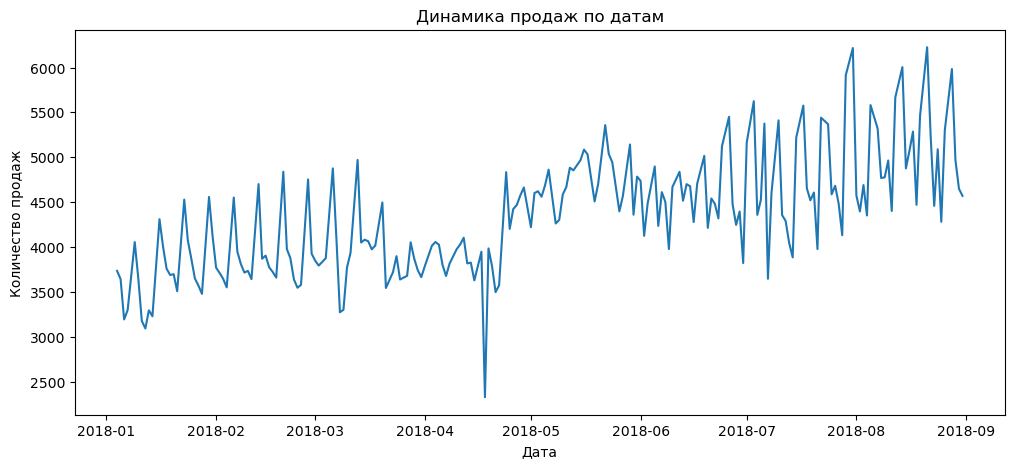

In [9]:
plt.figure(figsize=(12,5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [11]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [15]:
df['month'] = df['Дата'].dt.month
df['weekday'] = df['Дата'].dt.weekday
filtered = df[
    (df['Склад'] == 3) &
    (df['month'].isin([6,7,8])) &
    (df['weekday'] == 2)
]
filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [17]:
weather = pd.read_csv("weather.csv")  

weather["дата"] = pd.to_datetime(weather["дата"], format="%d.%m.%Y %H:%M", errors="coerce")
weather = weather.dropna(subset=["дата"])

weather["температура"] = pd.to_numeric(weather["температура"], errors="coerce")
weather = weather.dropna(subset=["температура"])

weather["дата"] = weather["дата"].dt.date
weather["дата"] = pd.to_datetime(weather["дата"])

In [18]:
daily_temp = (
    weather.groupby("дата", as_index=False)
           .agg(T=("температура", "mean"))
)

daily_temp.head()

,дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [19]:
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"])
daily_temp["дата"] = pd.to_datetime(daily_temp["дата"]) 

daily_temp = daily_temp.rename(columns={"дата": "Дата"})

merged = grouped_df.merge(daily_temp, on="Дата", how="left")
merged.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


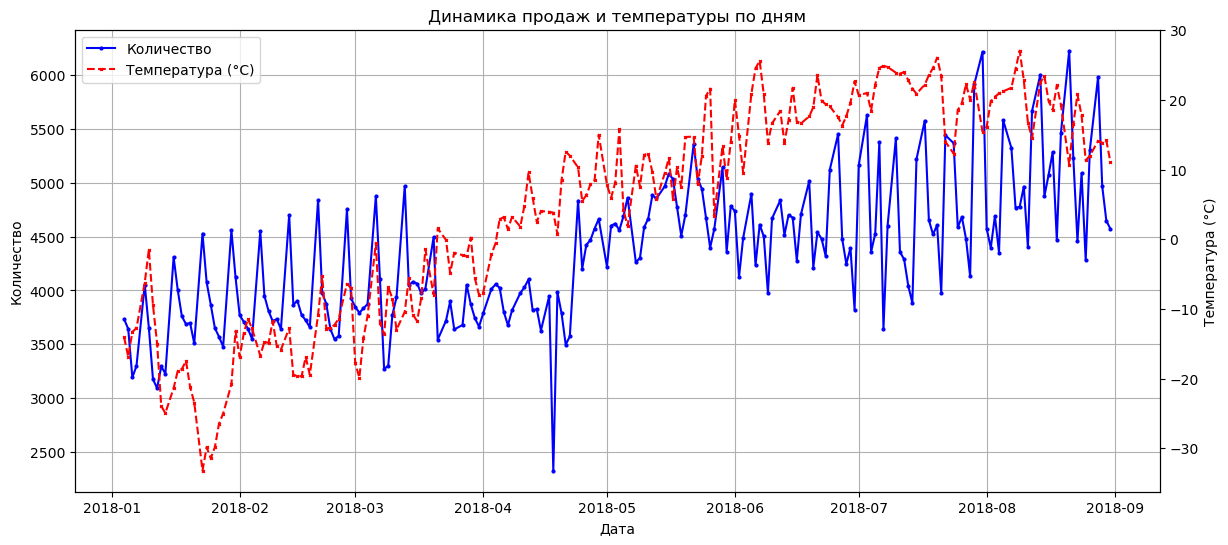

In [22]:
merged = merged.sort_values("Дата")

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    merged["Дата"], merged["Количество"],
    color="blue",
    linestyle='-', marker='o', markersize=2,
    label="Количество"
)
ax1.set_xlabel("Дата")
ax1.set_ylabel("Количество")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    merged["Дата"], merged["T"],
    color="red",
    linestyle='--', marker='x', markersize=2,
    label="Температура (°C)"
)
ax2.set_ylabel("Температура (°C)")

plt.title("Динамика продаж и температуры по дням")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()

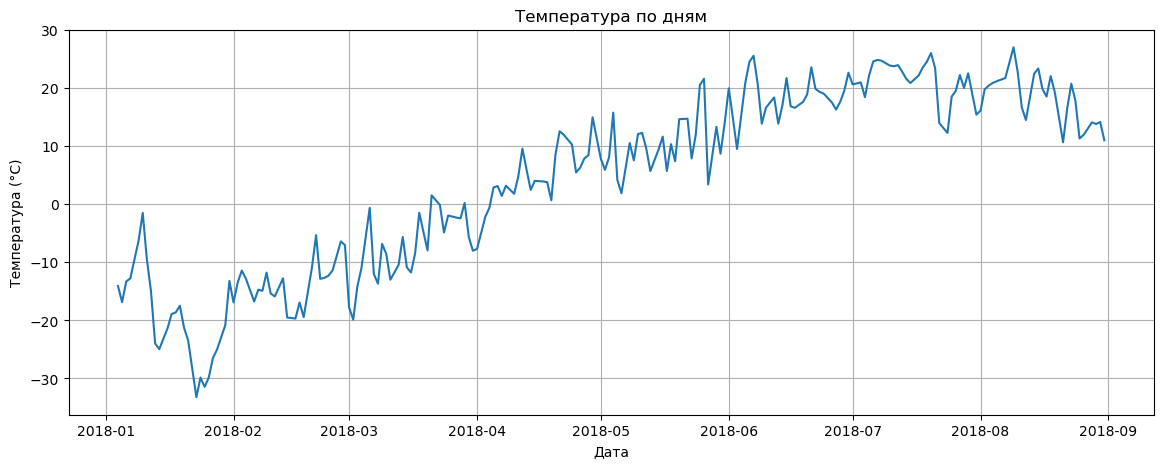

In [21]:
plt.figure(figsize=(14,5))
plt.plot(merged["Дата"], merged["T"])
plt.title("Температура по дням")
plt.xlabel("Дата")
plt.ylabel("Температура (°C)")
plt.grid(True)
plt.show()